# Noise lab — every generation of the rotor-noise model, on one trajectory

One clip per **generation** of this project's rotor-noise model, all rendered on the
**same rotor-speed trajectory**, with the **same render seed**, under the **same level
rule** — so what is left between two clips is the noise model and nothing else.

| source | generation | what it is |
|---|---|---|
| `LegacyRandom(seed)` | legacy | a fresh draw of the hand-written family (`data_processing.stochastic_rotor_noise`), i.e. what `kind: stochastic` with a `ranges:` block renders per window |
| `LegacyFit(name)` | legacy | one **stage-2 anchor fit** on the physical scale (`rig_sampler.FIT_PATHS` via `load_anchor`) — the measured rig each legacy bank was drawn around |
| `LegacyBank("easy"/"hard", i)` | legacy | entry `i` of `data/rig_banks/rig_{easy,hard}_n2048.json` — the **exact** preset bank the `rig_easy` / `rig_hard` arms trained on |
| `V2Fit("dregon")` | v2 | the round-5 **uncalibrated** single-regime fit (`render.render_noise`) |
| `V2Fit("michaels")` | v2 | the round-3 standby + cruise pair (`render.render_noise_regimes`, smoothstep 45 → 65 rev/s) |
| `V2Bank("easy"/"hard", i)` | v2 | entry `i` of `data/rig_banks/noise_v2_{easy,hard}_n2048.json` (= `dload:noise-v2-banks`) |

The training policies these come from differ in four things at once — the level rule,
render/flight reuse, the speed scaling and the trajectory source — so two arms' clips
are never comparable as heard. Here **one** trajectory is drawn and **one** level rule
is applied to all of them.

Logic lives in `noise_lab.py`; the cells below are thin. There are no sliders: a knob is
a keyword argument (`LegacyRandom(seed=3, harm_mean_db=6.0)`).

Rendering only — no forward model is ever evaluated on a fit pool.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import noise_lab as NL

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110})

## 1. Pick a trajectory

`NL.trajectory(kind, ...)` returns a Frame with **two** rotor tracks: `rps` at 100 Hz
for the plots and `rps_render`, the exact 16 kHz carrier every renderer consumes.

* `"fitted"` — the fitted trajectory model (`dload:rps-traj-fits`, `measurement_noise=False`);
  `rig=` is any name of `NL.traj_rig_names()` or `"posterior"` (a fresh drone from the
  hyperprior), plus `mean_shift=`, `mean_scale=`, `full_flight=`.
* `"real"` — a recording's telemetry: `dataset=`, `recording=`, `offset_s=`.
* `"full_flight"` / `"intermittent"` / `"ou"` — the hand-written `rps_synthesis` scaffold.

`rps_scale=` multiplies the whole track exactly (a stopped rotor stays stopped).

In [2]:
traj = NL.trajectory("fitted", rig="dregon", seed=0, duration_s=10.0)
NL.describe_traj(traj)

trajectory   : fitted  seed 0  10.0 s  rps_scale 1.00
  speeds     : 65.7-91.7 rev/s (mean 80.0)
  fitted rig : dregon -> dregon  (the rig's own fit)
  hover      : 80.5 rev/s   mu 84.2 77.0 85.0 75.8
  idle       : 16.7 15.3 16.9 15.0   ESC clamp 51.8-92.5 rev/s
  offset std : common 0.00 rev/s, per-rotor 1.59 2.95 0.77 0.92


## 2. The sources

Nine of them: one legacy random draw, the two legacy **stage-2 anchor fits** the banks
were drawn around, the two legacy bank entries the arms trained on, the two winning v2
fits, and the two v2 bank entries. `NL.legacy_fit_names()` lists every anchor
(`rig_sampler.FIT_PATHS`); `LegacyFit(name, clip=)` picks the per-clip export, defaulting
to the clip the published bank anchored on.

In [3]:
sources = [
    NL.LegacyRandom(seed=0),
    NL.LegacyFit("dregon_cruise_refined"),
    NL.LegacyFit("michael_cruise_refined"),
    NL.LegacyBank("easy", 0),
    NL.LegacyBank("hard", 0),
    NL.V2Fit("dregon"),
    NL.V2Fit("michaels"),
    NL.V2Bank("easy", 0),
    NL.V2Bank("hard", 0),
]
v2_dregon = next(s for s in sources if s.name == "v2-fit dregon")
for s in sources:
    print(f"{s.name:34s} {s.generation:7s} {s.entry}")

legacy-random s0       legacy  sample_params(seed=0, n_harmonics=80)
legacy-bank easy[0]    legacy  data/rig_banks/rig_easy_n2048.json: entry 0
legacy-bank hard[0]    legacy  data/rig_banks/rig_hard_n2048.json: entry 0
v2-fit dregon          v2      results/noise_v2/rounds/round5/fits/dregon_room2_floor__flight_profile.json
v2-fit michaels        v2      results/noise_v2/rounds/round3/fits/michaels_fly125_standby__flight.json + results/noise_v2/rounds/round3/fits/michaels_fly125_cruise__flight.json
v2-bank easy[0]        v2      data/rig_banks/noise_v2_easy_n2048.json: entry 0 (dregon_s3_00000)
v2-bank hard[0]        v2      data/rig_banks/noise_v2_hard_n2048.json: entry 0 (path_s3_00000)


## 3. Render them all on that trajectory

`level=("window", 0.1)` is a per-clip RMS: it is the only way to hear the generations
against each other, because the v2 sources are in **absolute fitted units** while the
legacy model has an arbitrary internal scale. The native alternative is the last cell.

The span warnings are the point of the exercise, not noise: a fitted trajectory of a rig
routinely leaves the carrier range its noise fit was identified on, and there the fitted
speed envelopes extrapolate.

In [4]:
frames = NL.render_all(sources, traj, seed=0, n_mics=1, level=("window", 0.1))
{k: tuple(v["audio"].data.shape) for k, v in frames.items()}

{'legacy-random s0': (1, 160000),
 'legacy-bank easy[0]': (1, 160000),
 'legacy-bank hard[0]': (1, 160000),
 'v2-fit dregon': (1, 160000),
 'v2-fit michaels': (1, 160000),
 'v2-bank easy[0]': (1, 160000),
 'v2-bank hard[0]': (1, 160000)}

## 4. Look at them

Spectrogram over the rotor-speed track, one pair per source, colour clipped to the top
45 dB (the renders span ~145 dB, so an autoscale washes the comb out).

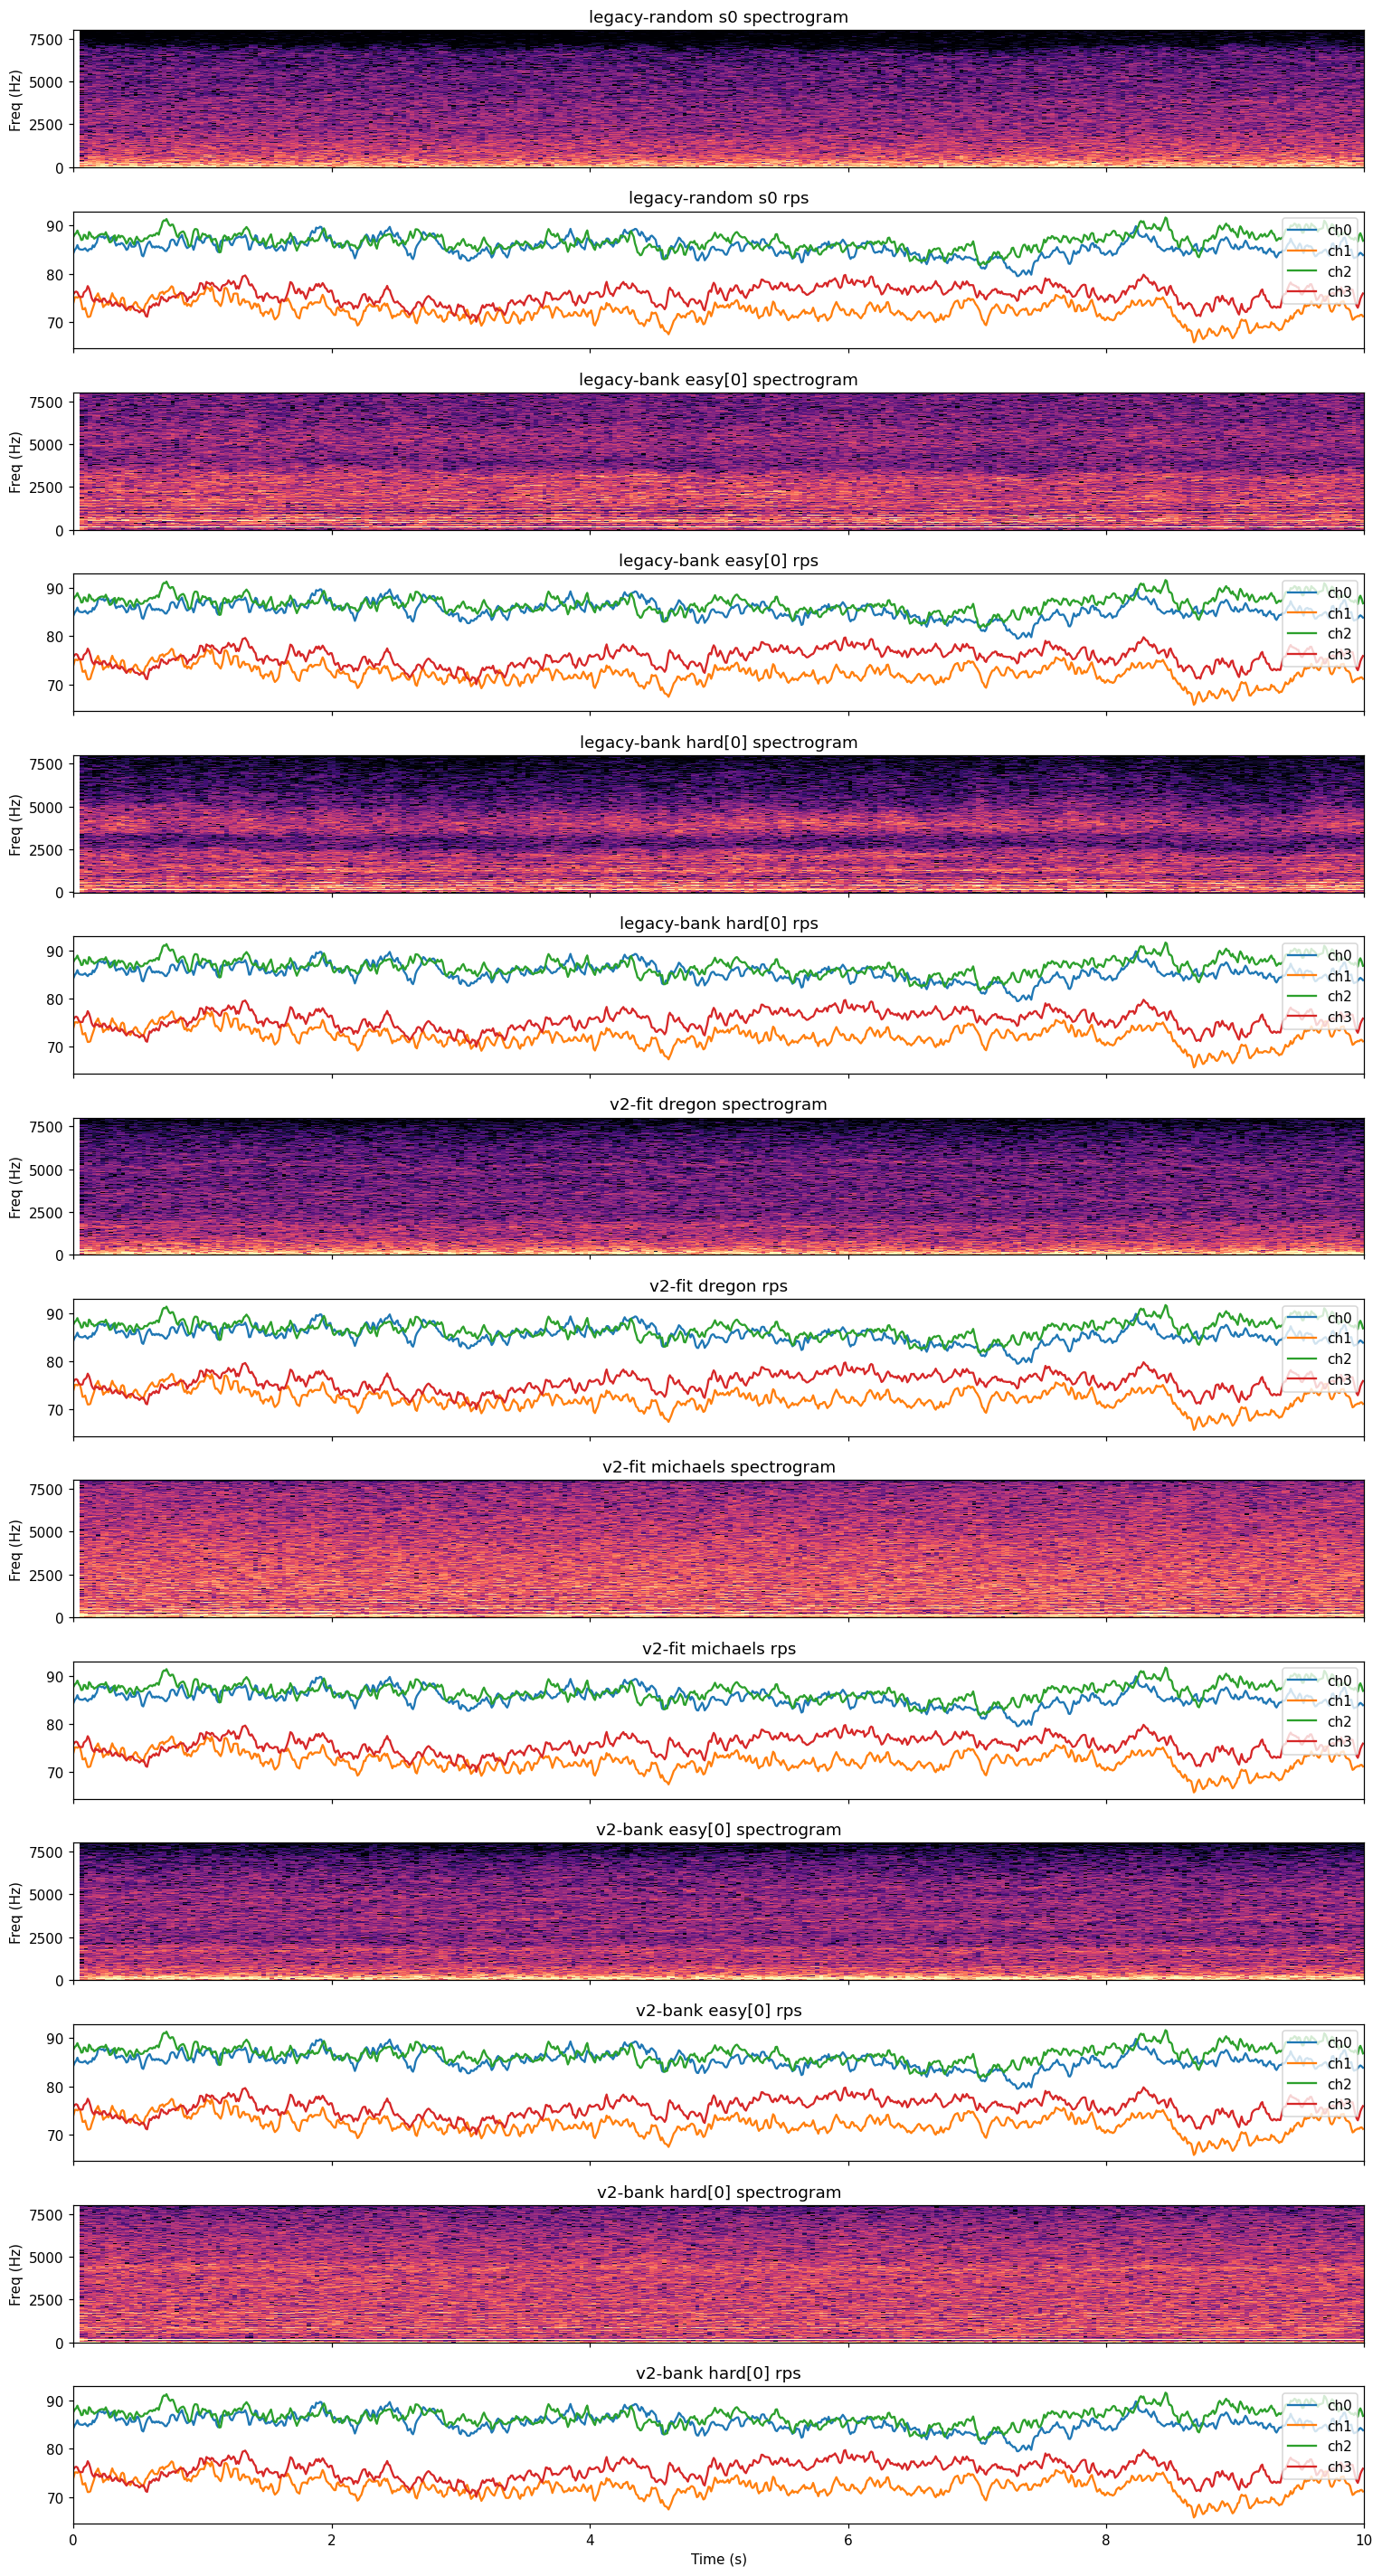

In [5]:
NL.show(frames, dyn_range=45.0, figsize=(14, 26))

## 5. Hear them

Same trajectory, same seed, same level rule — so the difference is the model.

In [6]:
NL.players(frames)

legacy-random s0   rms 0.1   peak 0.4394


legacy-bank easy[0]   rms 0.1   peak 0.4473


legacy-bank hard[0]   rms 0.1   peak 0.4779


v2-fit dregon   rms 0.1   peak 0.4563


v2-fit michaels   rms 0.1   peak 0.3897


v2-bank easy[0]   rms 0.1   peak 0.4282


v2-bank hard[0]   rms 0.1   peak 0.3981


## 5b. Turn the knobs — the old lab's sliders

`NL.tune(source, traj)` is `stochastic_noise_lab.Lab.panel` rebuilt over one source
and the **shared** trajectory: the amplitude means, the harmonic and floor wander in dB
and in seconds, the harmonic coherence, the floor-colour wander and its time, the
recording floor, the line mode, the clip length, **New random parameters** and
**Regenerate**. A slider move changes that number and leaves the draw's static random
parts alone; the button is what redraws them.

The trajectory and level controls the old lab had are gone on purpose — those are the
notebook's now, so a panel clip stays comparable with the seven above. A `LegacyBank`
source shows its numbers read-only (a bank entry is a *fitted* rig), and a v2 source
gets `comb_offset_db` and clip length only.

In [ ]:
NL.tune(sources[0], traj)

## 6. Read them

**R4's `line_width_db3` `peak_over_base_db`, framewise carrier-aligned profile mean over
frames × mics × rotors** — the statistic the round-4 anatomy published
(`round4/legacy_truth/anatomy.md`), ported from `scripts/noise_v2_widen_dregon.py` and
checked equal to it to the bit.

Each 8192-point Hann frame (hop 1024, 1.95 Hz per bin) is read at `k·f_r + offset` with
`f_r` the rotor's speed at that frame's centre sample, on a 0.5 Hz relative grid over
±0.75·f̄; those readings are averaged over every frame, mic and rotor, and the number is
`10·log10((peak + base)/base)` with `base` the median of the profile over the 0.45–0.7·f̄
annulus and `peak` the largest excess within ±2 grid points of the line. Aligning before
averaging is the point: the trajectory drifts 66–92 rev/s inside the clip, and an
unaligned average smears every line across the band it swept
(`round2/render_dregon/findings.md`). `NaN` = the band peak does not clear its own floor
(the R4 table's `—`).

For reference, the same estimator on the round-4 free-flight window read **+6.2 dB** at
k=1 on the real recording, **+18.2 dB** on the legacy render and **+7.4 dB** on the v2
render.

In [ ]:
NL.line_stats(frames, k_max=8).round(2)

## 7. Model against realisation, for one v2 source

The fit's expected periodogram against the clip's realised one, in the absolute units the
fit is stated in — the notebook's level gain is divided out first. Legacy sources have no
comparable forward model here and are refused by name.

In [ ]:
NL.expected_vs_realised(v2_dregon, frames[v2_dregon.name]);

## 8. The other level rule

`("flight", rms)` is the training policy's alternative: the number is the level **at the
reference speed**, and the clip's own floor envelope (`mean_r(speed**floor_exp) +
floor_static_rel`, the very factor each renderer shaped its floor with) is put back — so
a slow passage stays quieter than a fast one instead of every window leaving at the same
level. Each source reports its own envelope, so the rule means the same thing across
generations.

`level=None` keeps each generation's native scale: the fit's own absolute RMS for a v2
source, the model's arbitrary scale for a legacy one.

In [ ]:
flight = NL.render(v2_dregon, traj, seed=0, level=("flight", 0.1))
native = NL.render(v2_dregon, traj, seed=0, level=None)
for tag, f in (("window", frames[v2_dregon.name]), ("flight", flight), ("native", native)):
    m = f["meta"]
    print(f"{tag:7s} rms {float(m['rms']):.4g}   gain {float(m['level_gain']):.4g}")
NL.players({"v2-fit dregon, flight level": flight})